In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Load cleaned data
df = pd.read_csv("data/cleaned/cleaned_border_crossing.csv")
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
df.head()

(49993, 11)


,port_name,state,port_code,border,date,measure,value,latitude,longitude,point,month
0,Richford,Vermont,203,US-Canada Border,2026-01-01,Personal Vehicles,4050,45.011740,-72.588559,POINT (-72.588559 45.01174),1
1,Naco,Arizona,2603,US-Mexico Border,2026-01-01,Trucks,208,31.334084,-109.948413,POINT (-109.948413 31.334084),1
2,Naco,Arizona,2603,US-Mexico Border,2026-01-01,Truck Containers Empty,103,31.334084,-109.948413,POINT (-109.948413 31.334084),1
3,Sumas,Washington,3009,US-Canada Border,2026-01-01,Rail Containers Empty,338,49.002388,-122.264805,POINT (-122.264805 49.002388),1
4,Vanceboro,Maine,105,US-Canada Border,2026-01-01,Rail Containers Loaded,5908,45.568761,-67.428541,POINT (-67.428541 45.568761),1


In [3]:
# Build port-level features

# Base features
port_total   = df.groupby("port_name")["value"].sum().rename("total_crossings")
port_avg     = df.groupby("port_name")["value"].mean().rename("avg_crossings")
port_measure = df.groupby("port_name")["measure"].agg(
    lambda x: x.value_counts().index[0]).rename("top_measure")
port_border  = df.groupby("port_name")["border"].first().rename("border")
port_state   = df.groupby("port_name")["state"].first().rename("state")

# Personal vehicle ratio per port
personal_measures = [
    "Personal Vehicles",
    "Personal Vehicle Passengers",
    "Pedestrians",
    "Bus Passengers",
    "Train Passengers"
]
df["is_personal"] = df["measure"].isin(personal_measures)

personal_ratio = (
    df.groupby("port_name")[["value", "is_personal"]]
    .apply(lambda g: g.loc[g["is_personal"], "value"].sum() / g["value"].sum()
           if g["value"].sum() > 0 else 0, include_groups=False)
    .rename("personal_vehicle_ratio")
)

# Seasonality variance per port
seasonality = (
    df.groupby(["port_name", "date"])["value"]
    .sum()
    .reset_index()
    .groupby("port_name")["value"]
    .std()
    .fillna(0)
    .rename("seasonality_variance")
)

# Combine all features
port_df = pd.concat(
    [port_total, port_avg, port_border, port_state, port_measure,
     personal_ratio, seasonality],
    axis=1
).reset_index()

# Encode border after concat
port_df["border_encoded"] = (port_df["border"] == "US-Mexico Border").astype(int)

print(port_df.shape)  # should be (111, 9)

(111, 9)


In [4]:
# Cluster ports using KMeans k=4

features = port_df[[
    "total_crossings",
    "avg_crossings",
    "border_encoded",
    "personal_vehicle_ratio",
    "seasonality_variance"
]]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# k=4 selected based on elbow and silhouette scoring in clustering.ipynb
# Silhouette score at k=4 = 0.585 — see clustering.ipynb for full justification
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
port_df["cluster"] = kmeans.fit_predict(features_scaled)

print("Ports per cluster:")
print(port_df["cluster"].value_counts())

print("\nCluster averages:")
print(port_df.groupby("cluster")[[
    "total_crossings",
    "avg_crossings",
    "personal_vehicle_ratio",
    "seasonality_variance",
    "border_encoded"
]].mean().round(3))

Ports per cluster:
cluster
0    64
3    19
2    16
1    12
Name: count, dtype: int64

Cluster averages:
         total_crossings  avg_crossings  personal_vehicle_ratio  \
cluster                                                           
0           1.692926e+06       3264.758                   0.891   
1           1.003459e+08     206511.714                   0.880   
2           3.776488e+06       5420.334                   0.514   
3           1.895222e+07      45646.753                   0.964   

         seasonality_variance  border_encoded  
cluster                                        
0                   14562.626            0.00  
1                  359277.564            0.75  
2                   20508.583            0.00  
3                   69758.229            1.00  


In [5]:
# Decision tree — explaining cluster structure
# Cluster assignments are used as class labels
# Goal is interpretable rules, not prediction accuracy

feature_cols = [
    "total_crossings",
    "avg_crossings",
    "border_encoded",
    "personal_vehicle_ratio",
    "seasonality_variance"
]

X = port_df[feature_cols]
y = port_df["cluster"]

# Shallow depth keeps rules readable — we want insight, not accuracy
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X, y)

print(f"Training accuracy: {dt.score(X, y):.3f}")
print("\nFeature importances:")
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.round(4))

Training accuracy: 1.000

Feature importances:
personal_vehicle_ratio    0.3677
border_encoded            0.3654
seasonality_variance      0.2669
total_crossings           0.0000
avg_crossings             0.0000
dtype: float64


In [8]:
# Anomaly detection — Local Outlier Factor (LOF)
# LOF identifies ports whose local density differs significantly
# from their neighbors — these are anomalies in feature space,
# not just high-volume outliers
from sklearn.neighbors import LocalOutlierFactor

# n_neighbors=10 is reasonable for 111 ports
# contamination=0.05 flags approximately the top 5% as anomalies (~5-6 ports)
lof = LocalOutlierFactor(n_neighbors=10, contamination=0.05)
port_df["lof_label"] = lof.fit_predict(features_scaled)  # -1 = anomaly, 1 = normal
port_df["lof_score"] = -lof.negative_outlier_factor_      # higher = more anomalous

n_anomalies = (port_df["lof_label"] == -1).sum()
print(f"Ports flagged as anomalies: {n_anomalies}")
print(f"Total ports: {len(port_df)}")

Ports flagged as anomalies: 6
Total ports: 111


In [9]:
# View anomalous ports with their LOF scores and key features
# Sort by LOF score — higher score = more anomalous
anomalies = port_df[port_df["lof_label"] == -1].sort_values(
    "lof_score", ascending=False)

print("── Flagged anomalous ports ──")
print(anomalies[[
    "port_name", "cluster", "lof_score",
    "total_crossings", "personal_vehicle_ratio", "seasonality_variance", "border"
]].to_string(index=False))

── Flagged anomalous ports ──
             port_name  cluster  lof_score  total_crossings  personal_vehicle_ratio  seasonality_variance           border
            San Ysidro        1   3.167708        257101461                0.999282         510644.776095 US-Mexico Border
                Blaine        1   3.036124         40352994                0.859152         330211.309607 US-Canada Border
        Kenneth G Ward        0   2.362001          5404818                0.905536          49741.983176 US-Canada Border
Champlain Rouses Point        0   2.344670         16319596                0.761029         132351.372135 US-Canada Border
    Sault Sainte Marie        0   2.317470          5771515                0.893350          52957.774079 US-Canada Border
               Detroit        1   2.168679         58785097                0.685877         328316.083530 US-Canada Border


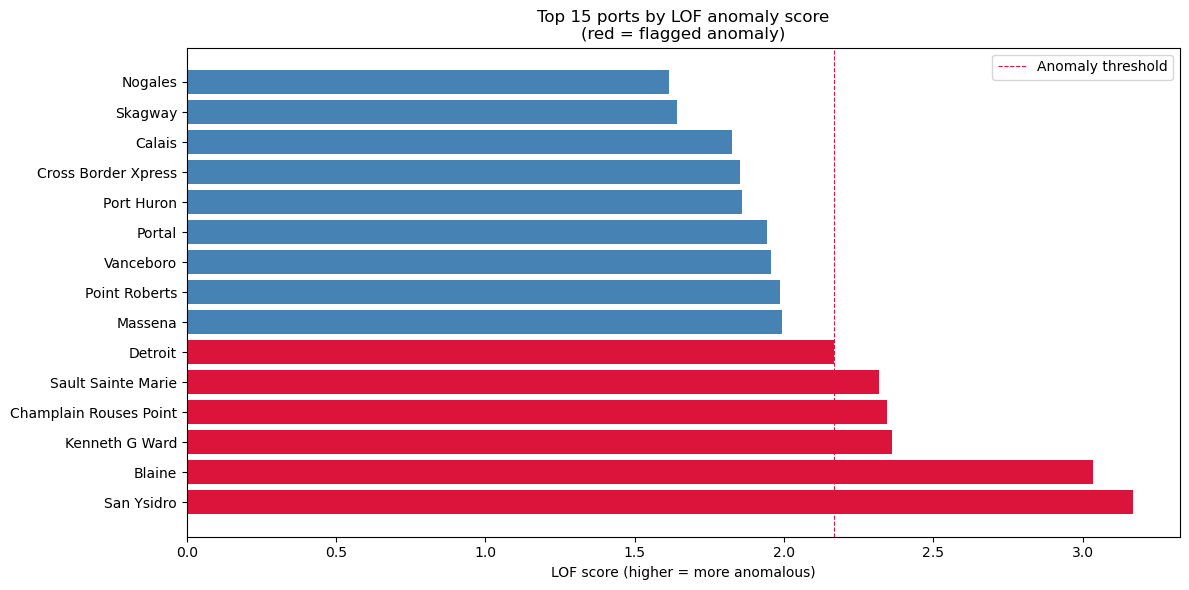

In [10]:
# Visualize anomaly scores for all ports 
# Show top 15 ports by LOF score
top15 = port_df.nlargest(15, "lof_score")

# Color flagged ports red, normal ports blue
colors = ["crimson" if x == -1 else "steelblue" 
          for x in top15["lof_label"]]

plt.figure(figsize=(12, 6))
bars = plt.barh(top15["port_name"], top15["lof_score"], color=colors)
plt.axvline(x=port_df[port_df["lof_label"] == -1]["lof_score"].min(),
            color="crimson", linestyle="--", linewidth=0.8, label="Anomaly threshold")
plt.title("Top 15 ports by LOF anomaly score\n(red = flagged anomaly)")
plt.xlabel("LOF score (higher = more anomalous)")
plt.legend()
plt.tight_layout()
plt.show()

# Anomaly findings

6 ports flagged as anomalous out of 111 total (5.4%). These are not necessarily data errors — each represents a genuine behavioral edge case that sits outside normal cluster patterns.

San Ysidro (score 3.17) Extreme outlier on all features. Highest volume (257M), highest seasonality variance (510,645), and near-perfect personal ratio
(0.999). Confirmed as a category of its own.

Blaine, WA (score 3.04) US-Canada port that behaves like a high-volume US-Mexico port. Seasonality variance of 330,211 places it with Mexico border ports
despite being on the Canada border. The Peace Arch crossing into Vancouver drives unusually high personal travel for a Canada port.

Detroit, MI (score 2.17) Unusual combination of high seasonality variance (328,316) and low personal ratio (0.686) for a US-Canada port. Most commercial
Canada ports have flat seasonality — Detroit handles both freight and tourism, making it behaviorally distinct from both groups.

Champlain Rouses Point, NY (score 2.34) Assigned to Cluster 0 (small quiet ports) but has volume and seasonality far above its cluster peers. Sits at the boundary between Cluster 0 and higher-volume groups.

Kenneth G Ward and Sault Sainte Marie (scores 2.36, 2.32) Flagged due to feature combinations that don't closely match their cluster neighbors. Genuine edge cases rather than errors.


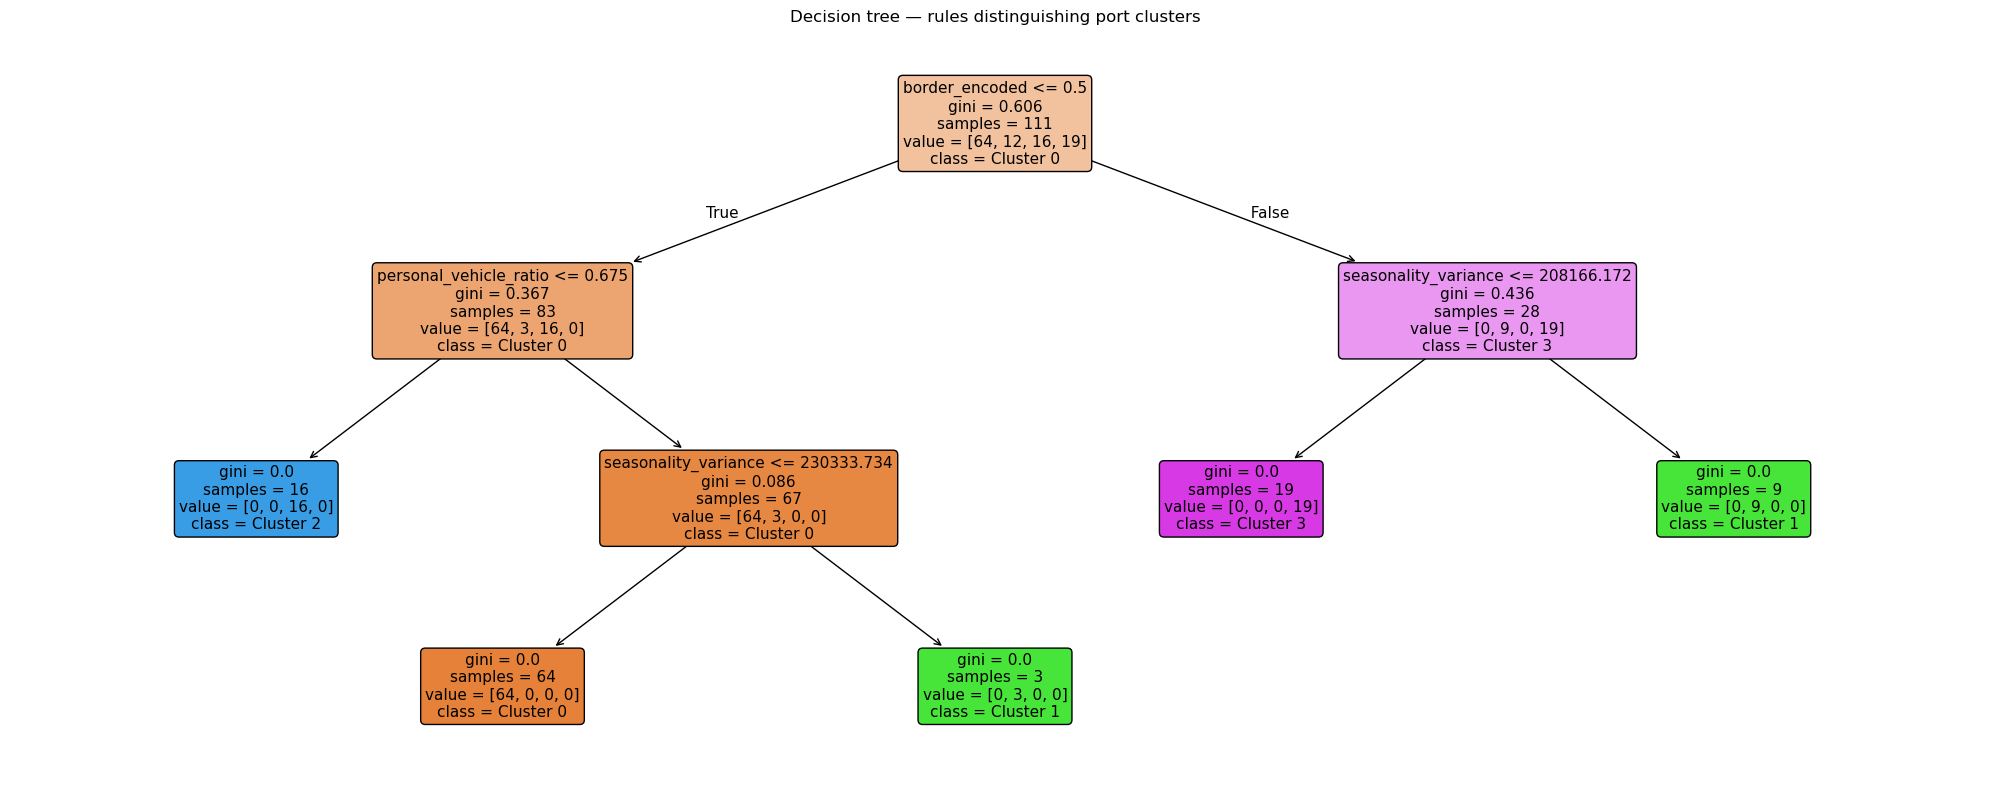

In [6]:
# Visualization of the decision tree 
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=feature_cols,
    class_names=[f"Cluster {i}" for i in range(4)],
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Decision tree — rules distinguishing port clusters")
plt.tight_layout()
plt.show()

In [7]:
# Print rules in normal language
rules = export_text(dt, feature_names=feature_cols)
print(rules)

|--- border_encoded <= 0.50
|   |--- personal_vehicle_ratio <= 0.68
|   |   |--- class: 2
|   |--- personal_vehicle_ratio >  0.68
|   |   |--- seasonality_variance <= 230333.73
|   |   |   |--- class: 0
|   |   |--- seasonality_variance >  230333.73
|   |   |   |--- class: 1
|--- border_encoded >  0.50
|   |--- seasonality_variance <= 208166.17
|   |   |--- class: 3
|   |--- seasonality_variance >  208166.17
|   |   |--- class: 1



# Named cluster profiles 

Cluster 0 — Small quiet US-Canada ports (64 ports)
Rule: Canada border + personal ratio > 0.68 + seasonality variance < 230,334
High personal vehicle ratio (0.891), very low volume, flat year-round traffic.
Mostly rural crossing points used for daily commuting and local travel.

Cluster 1 — High-volume seasonal ports (12 ports) ──
Rule: High seasonality variance (> 208,166–230,334)
Highest volume and strongest seasonal swings. Mix of Mexico (75%) and Canada.
These ports are driven by vacation and holiday travel peaks.

Cluster 2 — Commercial US-Canada ports (16 ports) ──
Rule: Canada border + personal ratio <= 0.68
Lowest personal vehicle ratio (0.514) — nearly half of traffic is commercial
freight. This cluster was invisible in M2 which used volume alone.
Key finding: US-Canada plays a larger commercial trade role than volume implies.

Cluster 3 — Steady US-Mexico commuter ports (19 ports) ──
Rule: Mexico border + seasonality variance < 208,166
100% US-Mexico, high personal ratio (0.964), moderate volume, low seasonality.
Consistent year-round commuter traffic rather than seasonal tourism.



═══════════════════════════════════════════════════════════════════════════════════════════════════════════════

DATA FINDINGS — DISCOVERY QUESTION PROGRESS

Q1: How do border crossing volumes correlate with seasonal trade cycles over time?

The decision tree identifies seasonality_variance as the third most important feature (importance 0.267) for distinguishing port clusters. High-volume ports (Cluster 1) show the strongest seasonal swings — variance above 208,166 — consistent with vacation and holiday travel driving peak months. Small US-Canada ports (Cluster 0) and commercial ports (Cluster 2) show flat year-round profiles with variance below 230,334, consistent with freight and commuter traffic that does not follow tourist cycles.

The tree rule makes this concrete: the same Canada port behaves differently depending on whether its seasonality variance crosses the 230,334 threshold — low variance means quiet rural port (Cluster 0), high variance means it behaves like a high-volume seasonal port (Cluster 1).

Q2: Are there identifiable shifts in trade flow between U.S.-Canada and U.S.-Mexico crossings over time?

The decision tree's root split is border_encoded — Mexico vs Canada is the single most informative feature (importance 0.365), confirming a structural difference between the two borders.

The most significant finding is Cluster 2: 16 US-Canada ports with a personal vehicle ratio below 0.68. These ports handle disproportionate commercial freight relative to their crossing volumes. This pattern was completely invisible in the M2 model which used volume alone — Cluster 2 ports looked identical to Cluster 0 ports by volume but are behaviorally distinct.

This suggests US-Canada crossings play a larger role in commercial trade flow than raw crossing counts imply, while US-Mexico crossings are dominated by personal and commuter traffic despite their higher total volumes.

═══════════════════════════════════════════════════════════════════════════════════════════════════════════════